### Langkah 1: Install Library

In [1]:
# Install library tambahan yang belum tersedia di Kaggle
!pip install -q Sastrawi google-play-scraper


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 11.1 MB/s eta 0:00:00


### Langkah 2: Import Library

In [2]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
import random
import tensorflow as tf
import plotly.express as px
import gc
import io
import huggingface_hub
from nltk.corpus import wordnet as wn
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from transformers import pipeline
from google.colab import drive
from google_play_scraper import app, reviews as scraper_reviews, Sort
from logging import exception

# Download NLTK data
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Langkah 3: Load Dataset dari Kaggle Input

In [3]:
import os

# Path dataset di Kaggle (sesuaikan nama dataset yang diupload)
# Struktur: /kaggle/input/<dataset-slug>/
DATASET_PATH = '/kaggle/input/datasets/ilhamrizalulfath/tangeranglive-reviews'

CSV_PATH     = os.path.join(DATASET_PATH, '/kaggle/input/datasets/ilhamrizalulfath/tangeranglive-reviews/Review Aplikasi Tangerang Live.csv')
SLANG_PATH   = os.path.join(DATASET_PATH, '/kaggle/input/datasets/ilhamrizalulfath/tangeranglive-reviews/slang.csv')
POS_TSV_PATH = os.path.join(DATASET_PATH, '/kaggle/input/datasets/ilhamrizalulfath/tangeranglive-reviews/positive.tsv')
NEG_TSV_PATH = os.path.join(DATASET_PATH, '/kaggle/input/datasets/ilhamrizalulfath/tangeranglive-reviews/negative.tsv')

# Load dataset
df = pd.read_csv(CSV_PATH)
print(f"Dataset berhasil dimuat! Total data: {len(df)} baris")
display(df.head())


Dataset berhasil dimuat! Total data: 7149 baris


,reviewId,userName,Review Teks,rating,thumbsUpCount,date
0,7dcaa7b7-5185-47ab-a9d5-c43f010fa8da,Pengguna Google,semoga bermanfaat untuk. masyarakat kota tange...,5,0,2026-08-05 22:11:50
1,b9e56ccd-b31f-4764-8bee-88bccf8146d5,Pengguna Google,disuruh perbarui apk tapi pas udh pengen di pe...,1,0,2026-08-05 20:41:48
2,63969f48-803e-41b1-974e-59479b7dc9c6,Pengguna Google,cukup baik,5,0,2026-08-05 17:38:04
3,85d0eaa3-9162-4293-94b7-a90a1674e3a8,Pengguna Google,"kebanyakan iklan, banyak kurang responnya",3,0,2026-08-04 22:16:52
4,f688eb94-e6c9-467b-ad73-d1699d496b53,Pengguna Google,keren lah.bisa ganti ktp yang rusak dan bikim ...,5,0,2026-08-04 16:37:30


### Langkah 4: EDA (Eksplorasi Data Awal)

#### 4.1 Informasi dataset

In [4]:
print("--- Info Dataset ---")
df.info()

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7149 entries, 0 to 7148
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   reviewId       7149 non-null   object
 1   userName       7149 non-null   object
 2   Review Teks    7149 non-null   object
 3   rating         7149 non-null   int64 
 4   thumbsUpCount  7149 non-null   int64 
 5   date           7149 non-null   object
dtypes: int64(2), object(4)
memory usage: 335.2+ KB


#### 4.2 Missing values

In [5]:
print("\n--- Jumlah Nilai Kosong ---")
print(df.isnull().sum())

print("\n--- Data Kosong pada Kolom 'Review Teks' ---")
display(df[df['Review Teks'].isnull()])


--- Jumlah Nilai Kosong ---
reviewId         0
userName         0
Review Teks      0
rating           0
thumbsUpCount    0
date             0
dtype: int64

--- Data Kosong pada Kolom 'Review Teks' ---


,reviewId,userName,Review Teks,rating,thumbsUpCount,date


#### 4.3 Data duplikat

In [6]:
duplicate_rows = df[df.duplicated()]
print(f"Jumlah data duplikat: {len(duplicate_rows)} baris")

Jumlah data duplikat: 0 baris


#### 4.4 Distribusi rating

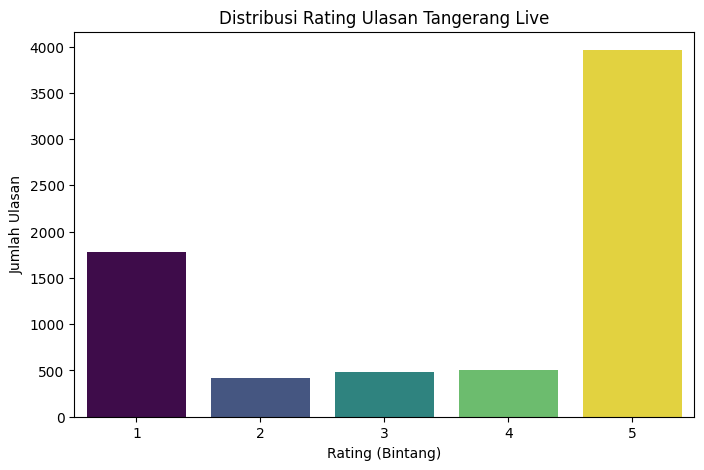

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x='rating', hue='rating', data=df, palette='viridis', legend=False)
plt.title('Distribusi Rating Ulasan Tangerang Live')
plt.xlabel('Rating (Bintang)')
plt.ylabel('Jumlah Ulasan')
plt.show()

#### 4.5 Sampel ulasan

In [8]:
print("--- Sampel Ulasan ---")
print(df[['Review Teks', 'rating']].head(10))

--- Sampel Ulasan ---
                                         Review Teks  rating
0  semoga bermanfaat untuk. masyarakat kota tange...       5
1  disuruh perbarui apk tapi pas udh pengen di pe...       1
2                                         cukup baik       5
3          kebanyakan iklan, banyak kurang responnya       3
4  keren lah.bisa ganti ktp yang rusak dan bikim ...       5
5                                              keren       5
6  ada notif harus di perbarui, tapi saat klik pe...       3
7  aplikasih bodoh, udh terdaftar tpi seminggu le...       1
8                                              keren       5
9                         sangat membantu masyarakat       5


### Langkah 5: Preprocessing

#### Langkah 5.1: Case Folding

In [9]:
# Case folding
df['text_casefold'] = df['Review Teks'].str.lower()

# Tampilkan 5 data setelah case folding (kolom asli dan hasil)
print("Setelah Case Folding:")
display(df[['Review Teks', 'text_casefold']].tail(5))

Setelah Case Folding:


,Review Teks,text_casefold
7144,Susah nya buat mencari kerja pribumi ataupun p...,susah nya buat mencari kerja pribumi ataupun p...
7145,Fitur2nya masih sedikit saran sih tambahin CCT...,fitur2nya masih sedikit saran sih tambahin cct...
7146,lebih memudahkan dan mengedukasi warga tangerang.,lebih memudahkan dan mengedukasi warga tangerang.
7147,Orang pribumi tangerang asli pasti download ni...,orang pribumi tangerang asli pasti download ni...
7148,Semoga bermanfaat....,semoga bermanfaat....


#### Langkah 5.2: Cleaning

In [10]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Hapus angka
    text = re.sub(r'\d+', '', text)
    # Hapus emoji
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)
    # Hapus tanda baca, ganti dengan spasi
    text = re.sub(r'[^\w\s]', ' ', text)
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Terapkan cleaning
df['text_clean'] = df['text_casefold'].apply(clean_text)

# Tampilkan 5 data setelah cleaning (sebelum vs sesudah)
print("Setelah Cleaning:")
display(df[['text_casefold', 'text_clean']].tail(5))

Setelah Cleaning:


,text_casefold,text_clean
7144,susah nya buat mencari kerja pribumi ataupun p...,susah nya buat mencari kerja pribumi ataupun p...
7145,fitur2nya masih sedikit saran sih tambahin cct...,fiturnya masih sedikit saran sih tambahin cctv...
7146,lebih memudahkan dan mengedukasi warga tangerang.,lebih memudahkan dan mengedukasi warga tangerang
7147,orang pribumi tangerang asli pasti download ni...,orang pribumi tangerang asli pasti download ni...
7148,semoga bermanfaat....,semoga bermanfaat


#### Langkah 5.3: Tokenizing

In [11]:
# Fungsi tokenisasi (hanya untuk tampilan)
def tokenize_display(text):
    if not isinstance(text, str):
        return []
    return word_tokenize(text)

# Buat kolom sementara untuk token
df['tokens'] = df['text_clean'].apply(tokenize_display)

# Tampilkan tabel: teks cleaning dan hasil token
print("Hasil Tokenizing:")
display(df[['text_clean', 'tokens']].tail(5))

# Hapus kolom sementara (opsional) - this line will be removed to retain 'tokens' column
# df.drop(columns=['tokens'], inplace=True)

Hasil Tokenizing:


,text_clean,tokens
7144,susah nya buat mencari kerja pribumi ataupun p...,"[susah, nya, buat, mencari, kerja, pribumi, at..."
7145,fiturnya masih sedikit saran sih tambahin cctv...,"[fiturnya, masih, sedikit, saran, sih, tambahi..."
7146,lebih memudahkan dan mengedukasi warga tangerang,"[lebih, memudahkan, dan, mengedukasi, warga, t..."
7147,orang pribumi tangerang asli pasti download ni...,"[orang, pribumi, tangerang, asli, pasti, downl..."
7148,semoga bermanfaat,"[semoga, bermanfaat]"


#### Langkah 5.4: Normalisasi Slang

In [12]:
# Load kamus slang (sesuaikan path)
slang_df = pd.read_csv(SLANG_PATH, sep=';', header=None, names=['slang', 'formal'], skiprows=1)
slang_df['slang'] = slang_df['slang'].astype(str).str.strip().str.lower()
slang_df['formal'] = slang_df['formal'].astype(str).str.strip().str.lower()
slang_dict = dict(zip(slang_df['slang'], slang_df['formal']))

def normalize_slang(tokens_list):
    if not isinstance(tokens_list, list):
        # If input is not a list, try to tokenize it first
        if isinstance(tokens_list, str):
            tokens_list = word_tokenize(tokens_list)
        else:
            return [] # Return empty list for non-string, non-list inputs
    normalized = [slang_dict.get(word, word) for word in tokens_list]
    return normalized # Return list of normalized tokens

# Terapkan normalisasi
df['text_norm'] = df['tokens'].apply(normalize_slang)

# Tampilkan 5 data setelah normalisasi (sebelum vs sesudah)
print("Setelah Normalisasi Slang:")
display(df[['tokens', 'text_norm']].tail(5))

Setelah Normalisasi Slang:


,tokens,text_norm
7144,"[susah, nya, buat, mencari, kerja, pribumi, at...","[susah, nya, buat, mencari, kerja, pribumi, at..."
7145,"[fiturnya, masih, sedikit, saran, sih, tambahi...","[fiturnya, masih, sedikit, saran, sih, tambahk..."
7146,"[lebih, memudahkan, dan, mengedukasi, warga, t...","[lebih, memudahkan, dan, mengedukasi, warga, t..."
7147,"[orang, pribumi, tangerang, asli, pasti, downl...","[orang, pribumi, tangerang, asli, pasti, unduh..."
7148,"[semoga, bermanfaat]","[semoga, bermanfaat]"


#### Langkah 5.5: Penanganan Negasi

In [13]:
def handle_negation(tokens_list):
    negation_words = ['tidak', 'gak', 'ga' , 'nggak', 'kurang', 'bukan', 'jangan', 'belom', 'belum']
    if not isinstance(tokens_list, list):
        return [] # Return an empty list if input is not a list

    new_tokens = []
    i = 0
    while i < len(tokens_list):
        current_token = tokens_list[i]
        if current_token in negation_words and i + 1 < len(tokens_list):
            new_tokens.append(current_token + '_' + tokens_list[i+1])
            i += 2 # Skip the next word as it's combined
        else:
            new_tokens.append(current_token)
            i += 1
    return new_tokens

# Terapkan penanganan negasi
df['text_neg'] = df['text_norm'].apply(handle_negation)

# Tampilkan 5 data setelah (sebelum vs sesudah)
print("Setelah Penanganan Negasi:")
display(df[['text_norm', 'text_neg']].tail(6))

Setelah Penanganan Negasi:


,text_norm,text_neg
7143,"[maju, terus, kota, tangerang, ku]","[maju, terus, kota, tangerang, ku]"
7144,"[susah, nya, buat, mencari, kerja, pribumi, at...","[susah, nya, buat, mencari, kerja, pribumi, at..."
7145,"[fiturnya, masih, sedikit, saran, sih, tambahk...","[fiturnya, masih, sedikit, saran, sih, tambahk..."
7146,"[lebih, memudahkan, dan, mengedukasi, warga, t...","[lebih, memudahkan, dan, mengedukasi, warga, t..."
7147,"[orang, pribumi, tangerang, asli, pasti, unduh...","[orang, pribumi, tangerang, asli, pasti, unduh..."
7148,"[semoga, bermanfaat]","[semoga, bermanfaat]"


#### Langkah 5.6: Stopword Removal

In [14]:
# Daftar stopword bahasa Indonesia dari Sastrawi
factory = StopWordRemoverFactory()
stopword_list = factory.get_stop_words()

# Tambahan stopword informal (opsional)
additional_stopwords = ['aja', 'saja', 'banget', 'kok', 'lagi', 'punya', 'terus', 'nih', 'loh', 'deh', 'dong', 'gitu', 'gini', 'udah', 'tapi', 'yg', 'nya', 'sih', 'pun', 'lah']
stopword_set = set(stopword_list + additional_stopwords)

# Pastikan kata negasi tidak dihapus (sudah digabung dengan underscore)
def remove_stopwords(tokens_list):
    if not isinstance(tokens_list, list):
        return [] # Return an empty list if input is not a list
    kept = [w for w in tokens_list if w not in stopword_set or '_' in w]
    return kept # Return a list of tokens

# Terapkan stopword removal
df['text_stop'] = df['text_neg'].apply(remove_stopwords)

# Tampilkan 5 data setelah (sebelum vs sesudah)
print("Setelah Stopword Removal:")
display(df[['text_neg', 'text_stop']].tail(5))

Setelah Stopword Removal:


,text_neg,text_stop
7144,"[susah, nya, buat, mencari, kerja, pribumi, at...","[susah, buat, mencari, kerja, pribumi, ataupun..."
7145,"[fiturnya, masih, sedikit, saran, sih, tambahk...","[fiturnya, sedikit, saran, tambahkan, cctv, la..."
7146,"[lebih, memudahkan, dan, mengedukasi, warga, t...","[lebih, memudahkan, mengedukasi, warga, tanger..."
7147,"[orang, pribumi, tangerang, asli, pasti, unduh...","[orang, pribumi, tangerang, asli, unduh, aplik..."
7148,"[semoga, bermanfaat]","[semoga, bermanfaat]"


#### Langkah 5.7: Stemming

In [15]:
# Inisialisasi stemmer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(tokens_list):
    if not isinstance(tokens_list, list):
        return []
    stemmed = []
    for word in tokens_list:
        if "_" in word:
            parts = word.split("_")
            stemmed_parts = [stemmer.stem(p) for p in parts]
            stemmed.append("_".join(stemmed_parts))
        else:
            stemmed.append(stemmer.stem(word))
    return stemmed

# Terapkan stemming
df['text_final'] = df['text_stop'].apply(stem_text)

# Tampilkan 5 data setelah stemming (sebelum vs sesudah)
print("Setelah Stemming (text_final):")
display(df[['text_stop', 'text_final']].tail(5))

Setelah Stemming (text_final):


,text_stop,text_final
7144,"[susah, buat, mencari, kerja, pribumi, ataupun...","[susah, buat, cari, kerja, pribumi, atau, data..."
7145,"[fiturnya, sedikit, saran, tambahkan, cctv, la...","[fiturnya, sedikit, saran, tambah, cctv, lapor..."
7146,"[lebih, memudahkan, mengedukasi, warga, tanger...","[lebih, mudah, edukasi, warga, tangerang]"
7147,"[orang, pribumi, tangerang, asli, unduh, aplik...","[orang, pribumi, tangerang, asli, unduh, aplik..."
7148,"[semoga, bermanfaat]","[moga, manfaat]"


### Langkah 6: Zero-Shot Classification

In [16]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from kaggle_secrets import UserSecretsClient
try:
    secrets  = UserSecretsClient()
    hf_token = secrets.get_secret("HF_TOKEN")
    print("HF_TOKEN berhasil dimuat.")
except Exception:
    hf_token = None
    print("HF_TOKEN tidak ditemukan. Lanjut tanpa autentikasi.")

import huggingface_hub
if hf_token:
    huggingface_hub.login(token=hf_token, add_to_git_credential=False)
    print("Login ke HuggingFace Hub berhasil.")

print("Memuat model zero-shot classification (facebook/bart-large-mnli)...")
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0,
    token=hf_token
)

candidate_labels = [
    "Kinerja Aplikasi", "Fungsionalitas", "Kemudahan Penggunaan",
    "Kualitas Layanan", "Keandalan dan Keamanan"
]

VERY_SHORT = {"bagus","jelek","ok","good","bad","sangat","kurang","biasa","oke","cukup"}

def get_aspect_single(text, min_length=10):
    if not isinstance(text, str) or len(text.strip()) < min_length:
        return "Lainnya (Teks Pendek)"
    if text.strip().lower() in VERY_SHORT:
        return "Lainnya (Teks Pendek)"
    return None

texts_series = df["text_final"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else (x if isinstance(x, str) else "")
)

mask_skip  = texts_series.apply(lambda t: get_aspect_single(t) is not None)
mask_model = ~mask_skip
results    = [""] * len(df)

for idx in df[mask_skip].index:
    results[df.index.get_loc(idx)] = get_aspect_single(texts_series[idx])

from tqdm import tqdm
texts_to_classify   = texts_series[mask_model].tolist()
indices_to_classify = list(df[mask_model].index)

BATCH_SIZE = 32  # Sesuaikan VRAM GPU
print(f"Total teks yang akan diklasifikasi: {len(texts_to_classify)}")

def batch_generator(lst, batch_size):
    for i in range(0, len(lst), batch_size):
        yield lst[i:i + batch_size]

all_labels = []
for batch in tqdm(batch_generator(texts_to_classify, BATCH_SIZE),
                  total=(len(texts_to_classify) + BATCH_SIZE - 1) // BATCH_SIZE,
                  desc="Zero-shot aspek (batch)"):
    batch_results = classifier(batch, candidate_labels, batch_size=BATCH_SIZE)
    if isinstance(batch_results, dict):
        batch_results = [batch_results]
    all_labels.extend([r["labels"][0] for r in batch_results])

for idx, label in zip(indices_to_classify, all_labels):
    results[df.index.get_loc(idx)] = label

df["aspek"] = results
print("\nDistribusi Aspek:"); print(df["aspek"].value_counts())

HF_TOKEN berhasil dimuat.
Login ke HuggingFace Hub berhasil.
Memuat model zero-shot classification (facebook/bart-large-mnli)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Total teks yang akan diklasifikasi: 5395


Zero-shot aspek (batch): 100%|██████████| 169/169 [07:21<00:00,  2.61s/it]


Distribusi Aspek:
aspek
Keandalan dan Keamanan    2398
Lainnya (Teks Pendek)     1754
Kinerja Aplikasi          1293
Fungsionalitas            1041
Kualitas Layanan           640
Kemudahan Penggunaan        23
Name: count, dtype: int64


### Langkah 7: Labeling Sentimen dengan InSet + WordNet

In [17]:
pos_lexicon = pd.read_csv(POS_TSV_PATH, sep='\t', names=['word', 'weight'], skiprows=1)
neg_lexicon = pd.read_csv(NEG_TSV_PATH, sep='\t', names=['word', 'weight'], skiprows=1)
pos_dict = dict(zip(pos_lexicon['word'], pos_lexicon['weight']))
neg_dict = dict(zip(neg_lexicon['word'], neg_lexicon['weight']))

def get_score(word):
    if word in pos_dict: return pos_dict[word]
    elif word in neg_dict: return neg_dict[word]
    else:
        synsets = wn.synsets(word, lang='ind')
        for syn in synsets:
            lemmas = [l.name() for l in syn.lemmas(lang='ind')]
            for lemma in lemmas:
                if lemma in pos_dict: return 1
                elif lemma in neg_dict: return -1
    return 0

def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return 'Negatif'
    score = 0
    words = text.split()
    negation_words = ['tidak', 'gak', 'ga', 'nggak', 'kurang', 'bukan', 'jangan', 'belom', 'belum']

    for word in words:
        if "_" in word:
            parts = word.split("_")
            if parts[0] in negation_words:
                base_score = get_score(parts[1])
                if base_score != 0:
                    score += (base_score * -1) # Inversi bobot!
        else:
            score += get_score(word)

    return 'Positif' if score > 0 else 'Negatif'

print("Sedang melakukan labeling sentimen...")
df['label'] = df['text_final'].apply(lambda x: get_sentiment(' '.join(x)) if isinstance(x, list) else get_sentiment(x))

print("\nDistribusi Label:")
print(df['label'].value_counts())

print("\nContoh hasil labeling:")
display(df[['text_final', 'label']].head(5))


Sedang melakukan labeling sentimen...

Distribusi Label:
label
Positif    5025
Negatif    2124
Name: count, dtype: int64

Contoh hasil labeling:


,text_final,label
0,"[moga, manfaat, masyarakat, kota, tangerang]",Positif
1,"[minta, baru, aplikasi, pada saat, pengin, bar...",Negatif
2,"[cukup, baik]",Negatif
3,"[banyak, iklan, banyak, kurang_responnya]",Positif
4,"[keren, ganti, kartu tanda duduk, rusak, bikim...",Positif


### Langkah 8: Pre-Modeling BiLSTM

#### Langkah 8.1: Encode label sentimen

In [18]:
le = LabelEncoder()
y = le.fit_transform(df['label'])
class_names = le.classes_
print("Encoding:", dict(zip(class_names, [0,1])))

Encoding: {'Negatif': 0, 'Positif': 1}


#### Langkah 8.2: Split data

In [19]:
# 80:10:10
X = df['text_final']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

Train: 5719, Validation: 715, Test: 715


#### Langkah 8.3: Tokenizer

In [20]:
max_words = 10000
max_len = 50
custom_filters = '!"#$%&()*+,-./:;<=>?@[\\]^`{|}~\t\n'
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>", filters=custom_filters)
tokenizer.fit_on_texts(df['text_final'])

#### Langkah 8.4: Konversi sequences

In [21]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

#### Langkah 8.5: Padding

In [22]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print(f"Shape X_train_pad: {X_train_pad.shape}")

Shape X_train_pad: (5719, 50)


### Langkah 9: Word Embedding FastText

> **Kaggle:** FastText diunduh dari internet. Pastikan Kaggle notebook menggunakan koneksi internet (Settings → Internet → ON).

In [23]:
# Unduh FastText bahasa Indonesia
# Catatan: Pastikan Kaggle notebook menggunakan koneksi internet (Settings > Internet > ON)
import urllib.request, gzip, shutil, os

FASTTEXT_GZ  = 'cc.id.300.vec.gz'
FASTTEXT_VEC = 'cc.id.300.vec'

if not os.path.exists(FASTTEXT_VEC):
    print("Mengunduh FastText vectors (~2.6 GB), harap tunggu...")
    urllib.request.urlretrieve(
        'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.vec.gz',
        FASTTEXT_GZ
    )
    print("Mengekstrak file...")
    with gzip.open(FASTTEXT_GZ, 'rb') as f_in, open(FASTTEXT_VEC, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    os.remove(FASTTEXT_GZ)
    print("Selesai!")
else:
    print("File FastText sudah tersedia, melewati unduhan.")

# Load vectors
def load_vectors(fname):
    fin = io.open(fname, 'r', encoding='utf-8', newline='\n', errors='ignore')
    header = fin.readline().split()
    n, d = int(header[0]), int(header[1])
    data = {}
    for line in fin:
        tokens = line.rstrip().split(' ')
        data[tokens[0]] = np.asarray(tokens[1:], dtype='float32')
    return data

print("Memuat FastText vectors...")
fasttext_vectors = load_vectors('cc.id.300.vec')

# Buat embedding matrix
embedding_dim = 300
word_index = tokenizer.word_index
nb_words = min(max_words, len(word_index) + 1)
embedding_matrix = np.zeros((nb_words, embedding_dim))
found = 0
for word, i in word_index.items():
    if i >= nb_words:
        continue
    vec = fasttext_vectors.get(word)
    if vec is not None:
        embedding_matrix[i] = vec
        found += 1
    else:
        # -------------------------------------------------------------------
        # SMART OOV INJECTION: Solusi untuk kata negasi rakitan (Out-Of-Vocabulary)
        # -------------------------------------------------------------------
        if "_" in word:
            parts = word.split("_")
            if parts[0] in ['tidak', 'gak', 'ga', 'nggak', 'kurang', 'bukan', 'jangan', 'belom', 'belum']:
                # Cek polaritas asli menggunakan fungsi kamus yang sudah ada
                try:
                    # Menggunakan get_score dari tahap sebelumnya (atau get_score_for_word)
                    if 'get_score' in globals():
                        score = get_score(parts[1])
                    else:
                        score = get_score(parts[1])
                except:
                    score = 0

                if score > 0:
                    # Kata dasar Positif (misal: "tidak_bagus") -> Injeksi vektor kata "jelek"
                    fallback_vec = fasttext_vectors.get('jelek')
                elif score < 0:
                    # Kata dasar Negatif (misal: "tidak_buruk") -> Injeksi vektor kata "bagus"
                    fallback_vec = fasttext_vectors.get('bagus')
                else:
                    fallback_vec = None

                if fallback_vec is not None:
                    embedding_matrix[i] = fallback_vec
                    found += 1
print(f"Embedding matrix shape: {embedding_matrix.shape}, ditemukan {found}/{nb_words} kata")

# Bersihkan memori
del fasttext_vectors
gc.collect()

Mengunduh FastText vectors (~2.6 GB), harap tunggu...
Mengekstrak file...
Selesai!
Memuat FastText vectors...
Embedding matrix shape: (4631, 300), ditemukan 3521/4631 kata


0

### Langkah 10: Arsitektur BiLSTM

In [24]:
# Inisiasi Nilai Awal
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Hitung class weight berdasarkan y_train
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weight:", class_weight_dict)

# One-hot encoding untuk label
y_train_onehot = to_categorical(y_train, num_classes=2)
y_val_onehot = to_categorical(y_val, num_classes=2)
y_test_onehot = to_categorical(y_test, num_classes=2)

# Multi-GPU Strategy (otomatis pakai semua GPU yang tersedia di Kaggle)
strategy = tf.distribute.MirroredStrategy()
print(f"Jumlah GPU yang digunakan: {strategy.num_replicas_in_sync}")

with strategy.scope():
    model = Sequential([
        Input(shape=(max_len,)),
        Embedding(nb_words, embedding_dim, weights=[embedding_matrix], trainable=True),
        SpatialDropout1D(0.5),
        Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer='l2')),
        Bidirectional(LSTM(32)),
        Dropout(0.5),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.0005), loss=CategoricalCrossentropy(label_smoothing=0.2), metrics=['accuracy'])

model.summary()

Class weight: {0: np.float64(1.683048852266039), 1: np.float64(0.711318407960199)}
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1786364889.854348      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10614 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786364889.856443      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Jumlah GPU yang digunakan: 2


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 300)        │     1,389,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 300)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 128)        │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,617,526 (6.17 MB)

 Trainable params: 1,617,526 (6.17 MB)

 Non-trainable params: 0 (0.00 B)

### Langkah 11: Training Model

In [25]:
checkpoint = ModelCheckpoint('/kaggle/working/model_tangerang_live_biner.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train_pad, y_train_onehot,
    epochs=15,
    batch_size=32,
    validation_data=(X_val_pad, y_val_onehot),
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

### Langkah 12: Evaluasi Model Sentimen

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
              precision    recall  f1-score   support

     Negatif       0.89      0.83      0.86       213
     Positif       0.93      0.96      0.94       502

    accuracy                           0.92       715
   macro avg       0.91      0.89      0.90       715
weighted avg       0.92      0.92      0.92       715



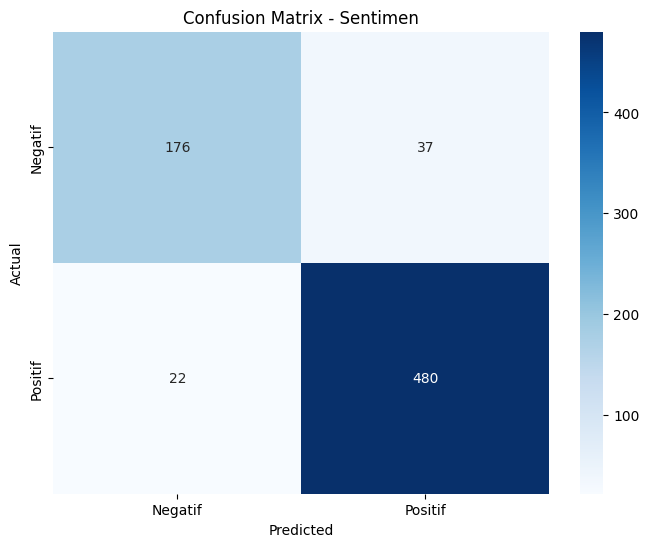

In [26]:
# Prediksi
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Sentimen')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#### Langkah 13: Visualisasi Learning Curves

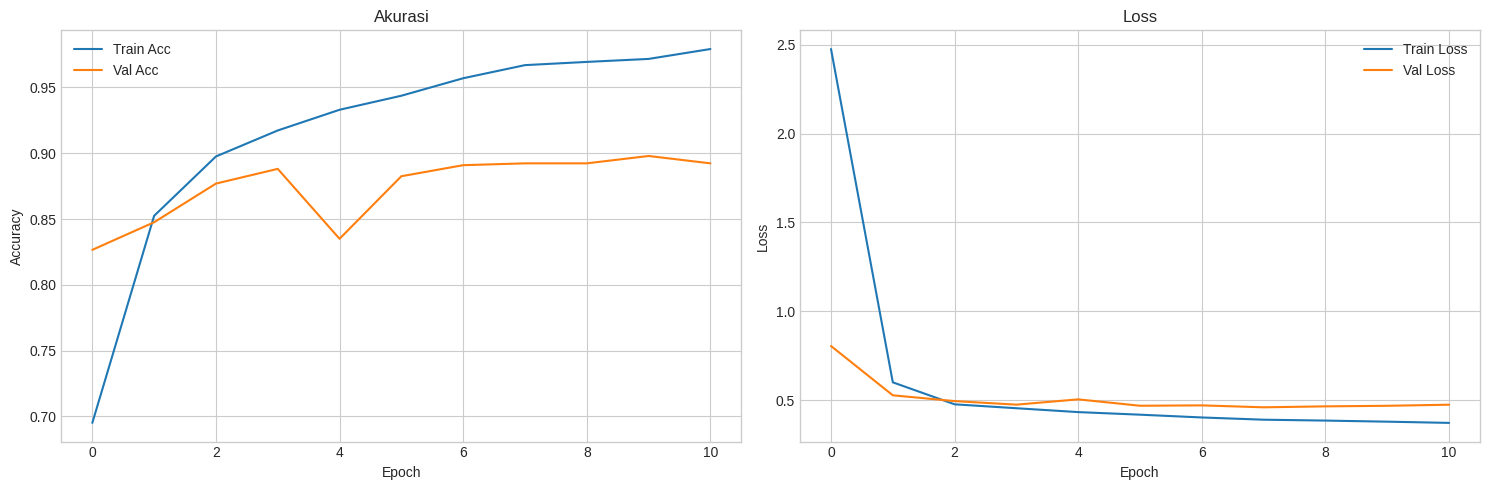

In [27]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

ax1.plot(history.history['accuracy'], label='Train Acc')
ax1.plot(history.history['val_accuracy'], label='Val Acc')
ax1.set_title('Akurasi')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

#### Langkah 14: Analisis Aspek

In [28]:
# Filter ulasan negatif
df_neg = df[df['label'] == 'Negatif']

# Hitung frekuensi aspek pada ulasan negatif
aspect_counts = df_neg['aspek'].value_counts().reset_index()
aspect_counts.columns = ['Aspek', 'Jumlah Keluhan']

# Filter out 'Lainnya (Teks Pendek)'
aspect_counts = aspect_counts[aspect_counts['Aspek'] != 'Lainnya (Teks Pendek)']

# Plot dengan plotly
fig = px.bar(aspect_counts, x='Aspek', y='Jumlah Keluhan',
             title='Distribusi Keluhan Berdasarkan Aspek (Ulasan Negatif)',
             color='Jumlah Keluhan', color_continuous_scale='Reds',
             text_auto=True) # Menambahkan label angka pada setiap bar
fig.show()

In [29]:
import pandas as pd

# 1. Definisikan pemetaan deskripsi fokus permasalahan
fokus_map = {
    'Kinerja Aplikasi': 'Mencakup kecepatan, responsivitas, serta stabilitas aplikasi saat digunakan.',
    'Fungsionalitas': 'Berkaitan dengan kelengkapan fitur dan kemampuan aplikasi menjalankan fungsinya.',
    'Kemudahan Penggunaan': 'Menunjukkan tingkat kemudahan pengguna dalam mengoperasikan aplikasi.',
    'Kualitas Layanan': 'Meliputi dukungan pelanggan, pelayanan administrasi, serta kepuasan interaksi.',
    'Keandalan & Keamanan': 'Berhubungan dengan konsistensi layanan dan perlindungan data pengguna.'
}

# 2. Filter data negatif (kecuali 'Lainnya (Teks Pendek)')
df_summary = df[(df['label'] == 'Negatif') & (df['aspek'] != 'Lainnya (Teks Pendek)')].copy()

# 3. Ambil contoh keluhan user (review asli) untuk setiap kategori
# Kita ambil 3 contoh ulasan unik per kategori dan gabungkan menjadi satu string
sample_reviews = df_summary.groupby('aspek')['Review Teks'].apply(lambda x: ' | '.join(x.unique()[:3])).reset_index()

# 4. Hitung jumlah keluhan
counts = df_summary['aspek'].value_counts().reset_index()
counts.columns = ['aspek', 'Jumlah Keluhan']

# 5. Gabungkan semua informasi menjadi satu tabel
tabel_ringkasan = counts.merge(sample_reviews, on='aspek')
tabel_ringkasan['Fokus Permasalahan Utama'] = tabel_ringkasan['aspek'].map(fokus_map)

# 6. Reorder dan Rename kolom
tabel_ringkasan = tabel_ringkasan[['aspek', 'Jumlah Keluhan', 'Fokus Permasalahan Utama', 'Review Teks']]
tabel_ringkasan.columns = ['Kategori', 'Jumlah Keluhan', 'Fokus Permasalahan', 'Keluhan User']

# Tampilkan tabel
display(tabel_ringkasan)

,Kategori,Jumlah Keluhan,Fokus Permasalahan,Keluhan User
0,Keandalan dan Keamanan,752,NaN,mantaapppp | blm pernah daftar katanya SDH ter...
1,Kinerja Aplikasi,534,"Mencakup kecepatan, responsivitas, serta stabi...",disuruh perbarui apk tapi pas udh pengen di pe...
2,Fungsionalitas,327,Berkaitan dengan kelengkapan fitur dan kemampu...,serba gercap | minta update tapi eror aplikasi...
3,Kualitas Layanan,194,"Meliputi dukungan pelanggan, pelayanan adminis...",Verifikasi data harus pake photo SELFI dengan ...
4,Kemudahan Penggunaan,7,Menunjukkan tingkat kemudahan pengguna dalam m...,Ribet daftar nya kek mau daftar pinjol | jelek...
